<a href="https://colab.research.google.com/github/anuragkba2027-lab/MIOM_Project/blob/anurag-process-control/notebooks/MIOM_standardized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIOM Project: SECom Dataset Analysis

Semiconductor yield prediction with anomaly detection (DBSCAN/KMeans), PCA, time-series.

**Run in venv with `jupyter notebook notebooks/MIOM_standardized.ipynb`**

## Imports

In [153]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / 'data').exists()),
    Path.cwd().resolve(),
)
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
TEMP_DIR = DATA_DIR / 'secom_temp'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)

# Style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## 1. Data Loading & Extraction

In [154]:
def load_and_extract_data(zip_path: Path | None = None, extract_dir: Path | None = None) -> pd.DataFrame:
    zip_path = Path(zip_path) if zip_path else RAW_DIR / 'secom.zip'
    extract_dir = Path(extract_dir) if extract_dir else TEMP_DIR
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # Load space-separated data
    data_path = extract_dir / 'secom.data'
    df = pd.read_csv(data_path, sep=r'\s+', header=None)
    df.columns = [f'feature_{i}' for i in range(df.shape[1])]
    return df

df_raw = load_and_extract_data()
if df_raw is not None:
    print(df_raw.shape)
    df_raw.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/raw/secom.zip'

## 2. EDA - Missing Values

In [ ]:
def plot_missing_analysis(df: pd.DataFrame):
    """Plot missing value analysis."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Col missing
    missing_cols = df.isnull().mean().sort_values(ascending=False).head(15)
    missing_cols.plot(kind='barh', ax=axes[0])
    axes[0].set_title('Top Missing Columns')

    # Row missing hist
    row_missing = df.isnull().mean(axis=1)
    row_missing.hist(bins=50, ax=axes[1])
    axes[1].set_title('Row Missing Ratio')

    # Heatmap
    sample_size = min(len(df), 500)
    sns.heatmap(df.sample(sample_size, random_state=42).isnull(), cbar=False, ax=axes[2])
    axes[2].set_title('Missing Pattern')

    plt.tight_layout()
    plt.show()

if 'df_raw' in locals(): plot_missing_analysis(df_raw)

## 3. Preprocessing

In [ ]:
def preprocess_data(df: pd.DataFrame, missing_threshold: float = 0.5) -> tuple:
    """Impute missing, add indicators, drop constants."""
    # Filter high-missing cols
    missing_ratio = df.isnull().mean()
    cols_keep = missing_ratio[missing_ratio < missing_threshold].index
    df_clean = df[cols_keep].copy()

    # Missing indicators
    missing_ind = df_clean.isnull().astype(int)
    missing_ind.columns = [col + '_missing' for col in df_clean.columns]

    # Median impute
    df_imputed = df_clean.fillna(df_clean.median())

    # Combine
    df_processed = pd.concat([df_imputed, missing_ind], axis=1)

    # Drop constants
    cols_drop = []
    for col in df_processed.columns:
        if df_processed[col].nunique() == 1:
            cols_drop.append(col)
    df_processed = df_processed.drop(columns=set(cols_drop))

    # Save
    df_imputed.to_csv(PROCESSED_DIR / 'Cleaned_data.csv', index=False)
    df_processed.to_csv(PROCESSED_DIR / 'Cleaned_data_Indicated.csv', index=False)

    return df_imputed, df_processed

if 'df_raw' in locals(): df_imputed, df_processed = preprocess_data(df_raw)
if 'df_processed' in locals(): print(df_processed.shape)

## 4. Scaling & PCA

In [ ]:
def apply_scaling_pca(df: pd.DataFrame, n_components: int = 200) -> pd.DataFrame:
    """Scale features, apply PCA."""
    original_cols = [col for col in df.columns if not col.endswith('_missing')]
    missing_cols = [col for col in df.columns if col.endswith('_missing')]

    scaler = StandardScaler()
    scaled_original = pd.DataFrame(
        scaler.fit_transform(df[original_cols]),
        columns=original_cols
    )

    df_scaled = pd.concat([scaled_original, df[missing_cols].reset_index(drop=True)], axis=1)
    df_scaled.to_csv(PROCESSED_DIR / 'Final_Scaled_data_Indicated.csv', index=False)

    # PCA
    n_components = min(n_components, df_scaled.shape[0], df_scaled.shape[1])
    pca = PCA(n_components=n_components)
    df_pca = pca.fit_transform(df_scaled)
    df_pca = pd.DataFrame(df_pca, columns=[f'PC_{i}' for i in range(n_components)])
    df_pca.to_csv(PROCESSED_DIR / 'secom_pca_ready.csv', index=False)

    # Scale PCA
    scaler_pca = StandardScaler()
    df_pca_scaled = pd.DataFrame(
        scaler_pca.fit_transform(df_pca),
        columns=df_pca.columns
    )
    df_pca_scaled.to_csv(PROCESSED_DIR / 'secom_pca_scaled.csv', index=False)

    # Plot variance
    fig, ax = plt.subplots(figsize=(8,5))
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    ax.plot(cum_var)
    ax.set_xlabel('Components')
    ax.set_ylabel('Cumulative Variance')
    ax.set_title('PCA Variance')
    ax.grid(True)
    plt.show()

    print(f"{n_components} PCs retain {cum_var[n_components - 1]*100:.1f}% variance")
    return df_pca_scaled

if 'df_processed' in locals(): df_pca_scaled = apply_scaling_pca(df_processed)

## 5. Clustering & Anomaly Detection

In [ ]:
def cluster_and_detect(df_pca: pd.DataFrame) -> pd.DataFrame:
    """KMeans + DBSCAN."""
    # KMeans silhouette
    scores = []
    for k in range(2, 10):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(df_pca)
        scores.append(silhouette_score(df_pca, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    axes[0].plot(range(2,10), scores, 'o-')
    axes[0].set_title('Silhouette')

    # Elbow
    inertia = []
    for k in range(1,15):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(df_pca)
        inertia.append(kmeans.inertia_)
    axes[1].plot(range(1,15), inertia, 'o-')
    axes[1].set_title('Elbow')
    plt.tight_layout()
    plt.show()

    # KMeans k=2
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(df_pca)

    # DBSCAN tuning
    neighbors = NearestNeighbors(n_neighbors=10)
    nbrs = neighbors.fit(df_pca)
    distances, _ = nbrs.kneighbors(df_pca)
    plt.plot(np.sort(distances[:,9]));
    plt.title('k-dist')
    plt.show()

    dbscan = DBSCAN(eps=16, min_samples=10)
    labels_db = dbscan.fit_predict(df_pca)

    df_results = pd.DataFrame(df_pca, columns=[f'PC_{i}' for i in range(df_pca.shape[1])])
    df_results['cluster'] = clusters
    df_results['dbscan_label'] = labels_db
    print('Clusters:', df_results['cluster'].value_counts())
    print('DBSCAN:', pd.Series(labels_db).value_counts())

    # Plots
    fig, axes = plt.subplots(1,3, figsize=(18,5))
    scatter = axes[0].scatter(df_results['PC_0'], df_results['PC_1'], c=df_results['cluster'], cmap='viridis', alpha=0.6)
    axes[0].set_title('KMeans')
    plt.colorbar(scatter, ax=axes[0])

    axes[1].scatter(df_results['PC_0'], df_results['PC_1'], c='blue', alpha=0.5, label='Normal')
    anom_k = df_results[df_results['cluster']==0]
    axes[1].scatter(anom_k['PC_0'], anom_k['PC_1'], c='red', label='Anoms')
    axes[1].legend()
    axes[1].set_title('KMeans Anoms')

    normal = df_results[df_results['dbscan_label'] != -1]
    axes[2].scatter(normal['PC_0'], normal['PC_1'], c='blue', alpha=0.5, label='Normal')
    anom_db = df_results[df_results['dbscan_label'] == -1]
    axes[2].scatter(anom_db['PC_0'], anom_db['PC_1'], c='red', label='DBSCAN Anoms')
    axes[2].legend()
    axes[2].set_title('DBSCAN')
    plt.tight_layout()
    plt.show()

    return df_results

if 'df_pca_scaled' in locals(): df_results = cluster_and_detect(df_pca_scaled)

## 6. Time-Series & Evaluation

In [ ]:
def time_analysis(df_results: pd.DataFrame, df_processed: pd.DataFrame):
    """Load labels, analyze over time."""
    label_candidates = [
        RAW_DIR / 'secom_labels.csv',
        TEMP_DIR / 'secom_labels.data',
        PROJECT_ROOT / 'secom_labels.csv',
    ]
    labels_path = next((path for path in label_candidates if path.exists()), None)
    if labels_path is None:
        raise FileNotFoundError('Could not locate a SECOM labels file.')

    if labels_path.suffix == '.csv':
        labels = pd.read_csv(labels_path).rename(columns={'label': 'true_label', 'date': 'timestamp'})
    else:
        labels = pd.read_csv(labels_path, sep=r'\s+', header=None, names=['true_label', 'timestamp'])

    labels = labels[['true_label', 'timestamp']]
    labels['timestamp'] = pd.to_datetime(labels['timestamp'], dayfirst=True)

    df_time = df_results.copy()
    df_time['true_label'] = labels['true_label']
    df_time['timestamp'] = labels['timestamp']
    df_time = df_time.sort_values('timestamp')

    df_time['is_anomaly'] = (df_time['dbscan_label'] == -1).astype(int)
    df_time['is_failure'] = (df_time['true_label'] == -1).astype(int)

    # Temporal features
    df_time['hour'] = df_time['timestamp'].dt.hour
    df_time['day_of_week'] = df_time['timestamp'].dt.day_name()
    df_time['month'] = df_time['timestamp'].dt.month

    # Plots over time
    fig, axes = plt.subplots(2,2, figsize=(15,10))
    df_time.set_index('timestamp')['cluster'].plot(style='.', ax=axes[0,0], alpha=0.5)
    axes[0,0].set_title('Clusters Over Time')

    df_time.set_index('timestamp')['dbscan_label'].plot(style='.', ax=axes[0,1], alpha=0.5)
    axes[0,1].set_title('DBSCAN Over Time')

    daily_anoms = df_time.set_index('timestamp').resample('D')['is_anomaly'].sum()
    daily_anoms.plot(ax=axes[1,0], title='Daily Anomalies')

    hour_fail = df_time.groupby('hour')['is_failure'].mean()
    hour_fail.plot(kind='bar', ax=axes[1,1], title='Failure Rate by Hour')
    plt.tight_layout()
    plt.show()

    order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    fig, axes = plt.subplots(1,3, figsize=(15,5))
    df_time.groupby('hour')['is_anomaly'].mean().plot(ax=axes[0], title='Anom Rate/Hour')
    df_time.groupby('day_of_week')['is_anomaly'].mean().reindex(order_days).plot(kind='bar', ax=axes[1], title='Anom Rate/Day')
    df_time.groupby('month')['is_anomaly'].mean().plot(kind='bar', ax=axes[2], title='Anom Rate/Month')
    plt.tight_layout()
    plt.show()

    # Evaluation
    df_time['future_failure'] = df_time['is_failure'].shift(-1)
    precision = df_time[df_time['is_anomaly'] == 1]['future_failure'].mean()
    recall = df_time[df_time['future_failure'] == 1]['is_anomaly'].mean()
    print(f"Precision (next failure | anomaly): {precision:.3f}")
    print(f"Recall (anomaly | next failure): {recall:.3f}")

    # Anomaly feature diffs
    df_scaled_num = df_processed.select_dtypes(include=[np.number])
    anom_idx = df_time[df_time['dbscan_label'] == -1].index
    anoms = df_scaled_num.iloc[anom_idx]
    normal = df_scaled_num.drop(anom_idx)
    diff = (anoms.mean() - normal.mean()).abs().sort_values(ascending=False).head(10)
    print("Top differing features:")
    print(diff)

    return df_time

if 'df_results' in locals() and 'df_processed' in locals(): df_time = time_analysis(df_results, df_processed)

## Summary
- Processed data saved to `data/processed/`
- DBSCAN eps=16 detects anomalies predictive of future failures (precision/recall shown above).
- Ready for modeling.

# 🔹 SPC Six Sigma Analysis (Anurag)


# Import Libraries


In [155]:
import pandas as pd
import numpy as np

Load Sensor Data

In [156]:
sensor_df = pd.read_csv("Final_Scaled_data_Indicated.csv")

Load PCA Data

In [157]:
pca_df = pd.read_csv("secom_pca_scaled.csv")

Load Labels

In [158]:
labels = pd.read_csv("secom_labels.data", sep=" ", header=None)
labels.columns = ["label", "timestamp"]

Clean Label Column

In [159]:
labels["label"] = labels["label"].astype(int)

Attach Only Label

In [160]:
sensor_df["label"] = labels["label"]
pca_df["label"] = labels["label"]

Basic Checks

In [161]:
print(sensor_df.shape)
print(pca_df.shape)
print(labels.shape)

(1567, 958)
(1567, 201)
(1567, 2)


Align Rows

In [162]:
# Reset index to avoid mismatch
sensor_df = sensor_df.reset_index(drop=True)
pca_df = pca_df.reset_index(drop=True)
labels = labels.reset_index(drop=True)

Sanity Check

In [163]:
assert len(sensor_df) == len(pca_df) == len(labels), "Row mismatch!"

Preview Data

In [164]:
sensor_df.head()

,ID,feature_0,feature_1,feature_2,feature_3,feature_4,feature_6,feature_7,feature_8,feature_9,...,feature_569_missing,feature_582_missing,feature_583_missing,feature_584_missing,feature_585_missing,feature_586_missing,feature_587_missing,feature_588_missing,feature_589_missing,label
0,0,0.224463,0.849523,-0.436430,0.035804,-0.050121,-0.564354,0.265894,0.509848,1.128455,...,1,0,0,0,0,1,1,1,1,-1
1,1,1.107287,-0.383106,1.016977,0.155282,-0.059585,0.197639,0.321868,0.457021,0.022620,...,1,0,0,0,0,0,0,0,0,-1
2,2,-1.114000,0.798901,-0.481447,0.688278,-0.047447,-0.906768,0.254699,-0.260885,0.327222,...,0,0,0,0,0,0,0,0,0,1
3,3,-0.350156,-0.199072,-0.051705,-1.104376,-0.050831,0.502662,-0.013974,0.343240,-0.765369,...,0,0,0,0,0,0,0,0,0,-1
4,4,0.242296,0.087328,1.117227,-0.156616,-0.047033,-0.115954,0.187531,0.545066,-0.149545,...,1,0,0,0,0,0,0,0,0,-1


In [165]:
pca_df.head()

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,...,PC_191,PC_192,PC_193,PC_194,PC_195,PC_196,PC_197,PC_198,PC_199,label
0,-0.346428,0.743551,1.072479,-0.626297,-0.481146,-0.532308,0.674180,-0.090721,-0.535556,0.377227,...,-0.998246,-1.445689,0.366971,0.493249,-1.325033,1.691904,0.282667,0.910545,-0.352580,-1
1,-0.449947,0.227404,0.821659,-0.516369,-0.628958,-0.636529,0.679510,0.490596,-0.987091,0.201567,...,-0.037928,0.448618,-1.173327,-0.996136,0.515960,-0.228228,0.310982,-0.890801,-0.909703,-1
2,0.019040,0.249711,0.342721,-0.102865,0.611454,-0.700442,0.291836,0.090292,-0.865089,0.234510,...,1.135117,1.313348,0.953930,0.226517,-0.330848,-1.912875,-0.765449,-0.780031,1.054175,1
3,0.217027,1.295131,1.186451,-0.907835,0.610636,-2.799127,-1.634783,-3.456204,-2.746507,2.728187,...,0.335961,-0.092360,-0.314337,-0.035375,0.738612,-0.172548,-0.077291,0.654921,-0.359496,-1
4,0.159434,0.625267,0.710345,-0.003154,1.152140,-1.630657,-0.569639,-1.098329,0.659916,0.969723,...,-0.750123,-0.472425,0.926072,0.340027,1.119186,-0.549312,-0.307748,-0.205678,1.333820,-1


Split features: Real sensors vs _missing indicators

In [166]:
missing_cols = [col for col in sensor_df.columns if "missing" in col]

real_cols = [
    col for col in sensor_df.columns
    if col not in missing_cols + ["label", "ID"]
]

sensor_real = sensor_df[real_cols]

# 3.4 Defect Detection & Quantification

 ### A) Sensor-Level (Local)

 Apply ±3σ per feature
- → Flag rows where ANY feature violates limits
- → Sensor anomaly flag

## What We Are Doing

**For each sensor**:
    check if value deviates beyond ±3σ

**If ANY sensor violates**:
    mark that row as anomaly

Step 1: Use Only Real Sensor Features (excluse missing indicator features)

In [167]:
sensor_features = sensor_real.copy()

Step 2: Compute Mean and Std

In [168]:
mean = sensor_features.mean()
std = sensor_features.std()

Step 3: Compute Z-Scores

In [169]:
z_scores = (sensor_features - mean) / std

Step 4: Apply ±3σ Rule

If any feature in a row exceeds ±3 → anomaly

In [170]:
sensor_anomaly_flag = (np.abs(z_scores) > 3).any(axis=1)

Step 5: Add Flag to Dataset

In [171]:
sensor_df["sensor_anomaly"] = sensor_anomaly_flag

Step 6: Check Results

TRUE  → abnormal process condition detected  
FALSE → normal observation

**IMPORTANT INTERPRETATION**

👉 This does NOT mean:

“product is defective”

👉 It means:

“process conditions were abnormal”

In [172]:
sensor_df["sensor_anomaly"].value_counts()

,count
sensor_anomaly,
True,1279
False,288


Step 7: Defect Rate (Sensor-Level)

In [173]:
sensor_defect_rate = sensor_anomaly_flag.mean()
print("Sensor-level defect rate:", sensor_defect_rate)

Sensor-level defect rate: 0.8162093171665603


# **VALIDATION WITH LABELS**
Do these anomalies actually correspond to defective products?

### Step 1: Understand Labels

-1 → good product  
 1 → defective product

### Step 2: Convert Labels to Binary

👉 Easier for evaluation

In [174]:
sensor_df["true_defect"] = (sensor_df["label"] == 1).astype(int)

### Step 3: Convert Your Prediction

In [175]:
sensor_df["pred_defect"] = sensor_df["sensor_anomaly"].astype(int)

### Step 4: Create Confusion Matrix

In [176]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(sensor_df["true_defect"], sensor_df["pred_defect"])

cm_df = pd.DataFrame(cm,
                     index=["Actual Normal", "Actual Defect"],
                     columns=["Predicted Normal", "Predicted Defect"])

cm_df

,Predicted Normal,Predicted Defect
Actual Normal,270,1193
Actual Defect,18,86


Heat Map View

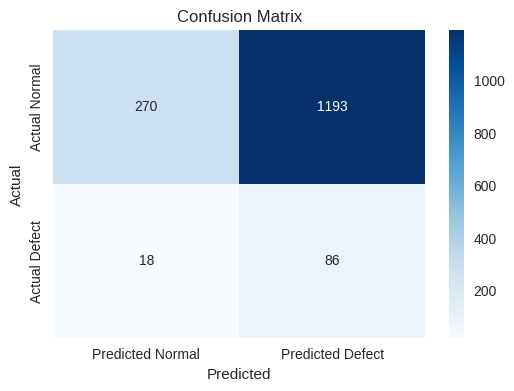

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

TP = 86   → correctly detected defects  
FP = 1193 → false alarms  
FN = 18   → missed defects  
TN = 270  → correctly normal  

🔹 1. Recall
Recall = TP / (TP + FN)
       = 86 / (86 + 18)
       ≈ 82.7%



✅ Interpretation:
The model successfully detects ~83% of defective products.

👉 This is GOOD

🔹 2. Precision

Precision = TP / (TP + FP)
          = 86 / (86 + 1193)
          ≈ 6.7%

⚠️ Interpretation:

Only ~6.7% of predicted defects are actually defective.

👉 This is VERY LOW

🔹 3. False Alarm Rate (Big Insight)
FP is very high (1193)

⚠️ Interpretation:

The model frequently flags normal products as defective.

--


--

# 3.4(B) PCA-Level Defect Detection

Step 1: Prepare PCA Features

👉 Remove label column

In [178]:
pca_features = pca_df.drop(columns=["label"])

Step 2: Compute Mean & Std

In [179]:
mean_pca = pca_features.mean()
std_pca = pca_features.std()

Step 3: Compute Z-Scores

In [180]:
z_scores_pca = (pca_features - mean_pca) / std_pca

Step 4: Apply ±3σ Rule

In [181]:
pca_anomaly_flag = (np.abs(z_scores_pca) > 3).any(axis=1)

Step 5: Add to Dataset

In [182]:
pca_df["pca_anomaly"] = pca_anomaly_flag

Step 6: Defect Rate (PCA-Level)

In [183]:
pca_defect_rate = pca_anomaly_flag.mean()
print("PCA-level defect rate:", pca_defect_rate)

PCA-level defect rate: 0.38481174218251435


Step 7: Validation

In [184]:
pca_df["true_defect"] = (pca_df["label"] == 1).astype(int)
pca_df["pred_defect"] = pca_df["pca_anomaly"].astype(int)

Confusion Matrix

In [185]:
from sklearn.metrics import confusion_matrix

cm_pca = confusion_matrix(pca_df["true_defect"], pca_df["pred_defect"])
print(cm_pca)

[[914 549]
 [ 50  54]]


Heat Map

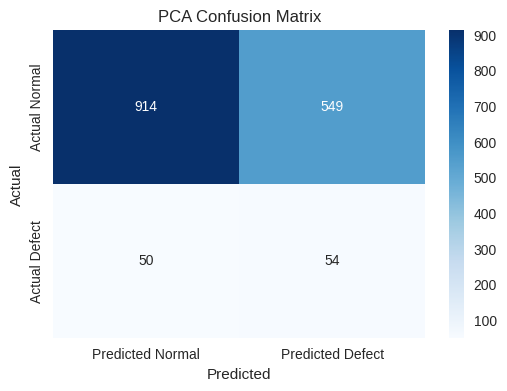

In [186]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_pca_df = pd.DataFrame(cm_pca,
                        index=["Actual Normal", "Actual Defect"],
                        columns=["Predicted Normal", "Predicted Defect"])

plt.figure(figsize=(6,4))
sns.heatmap(cm_pca_df, annot=True, fmt="d", cmap="Blues")

plt.title("PCA Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

TP = 54   → correctly detected defects  
FP = 549  → false alarms  
FN = 50   → missed defects  
TN = 914  → correctly normal  

🔹 1. Recall

Recall = TP / (TP + FN) = 54 / (54 + 50) ≈ 51.9%

✅ Interpretation: The model detects ~52% of defective products.

👉 This is MODERATE / LOW

🔹 2. Precision

Precision = TP / (TP + FP) = 54 / (54 + 549) ≈ 8.9%

⚠️ Interpretation:
Only ~8.9% of predicted defects are actually defective.

👉 This is LOW (but better than sensor model)

🔹 3. False Alarm Rate (Big Insight)
FP is still high (549)

⚠️ Interpretation:
The model still flags many normal products as defective, but significantly fewer than the sensor-based approach.

In [187]:
print("Sensor Defect Rate:", sensor_defect_rate)
print("PCA Defect Rate:", pca_defect_rate)

Sensor Defect Rate: 0.8162093171665603
PCA Defect Rate: 0.38481174218251435


# **CRITICAL COMPARISON**

| Metric          | Sensor        | PCA                |
| --------------- | ------------- | ------------------ |
| Recall          | ✅ High (~83%) | ❌ Low (~52%)       |
| Precision       | ❌ Very low    | ⚠️ Slightly better |
| False Positives | ❌ Very high   | ✅ Reduced          |
| False Negatives | ✅ Low         | ❌ Higher           |


--

--

🔹 Sensor Model

Very sensitive  
→ catches most defects  
→ but too many false alarms

🔹 PCA Model

More conservative  
→ fewer false alarms  
→ but misses many defects


--

--

# 3.5 Process Capability Analysis

Select key sensors (top contributors / unstable ones)

Compute:
μ (mean), σ (std)
* USL = μ + 3σ
* LSL = μ - 3σ
* Cp  = (USL - LSL) / (6σ)
* Cpk = min[(USL-μ)/(3σ), (μ-LSL)/(3σ)]

**Interpret:**
- Cp > 1 → capable
- Cpk < 1 → off-centered / unstable


**GOAL**

Select important sensors based on:
1. Frequently crossing ±3σ  → unstable sensors (**🔹 Group 1: Unstable Sensors**)
2. Different behavior in defect vs normal → impactful sensors (**🔹Group 2: Defect-Sensitive Sensors**)

### **Group 1**

###STEP 1: Sensors Crossing ±3σ Frequently

Count violations per sensor

In [188]:
violation_counts = (np.abs(z_scores) > 3).sum().sort_values(ascending=False)

View top unstable sensors

In [189]:
violation_counts.head(10)

,0
feature_38,71
feature_576,70
feature_574,68
feature_577,62
feature_573,60
feature_572,60
feature_575,57
feature_558,56
feature_295,54
feature_160,54


Select top sensors

In [190]:
top_violation_sensors = violation_counts.head(5).index.tolist()

### **Group 2**

STEP 2: Sensors Differing Between Defect vs Normal

  CASE 1. Normal products (label = -1)  
  CASE 2. Defective products (label = 1)

**For Each Sensor:** we compare

- Average value in defective products (label=1)

   vs  
- Average value in normal products (lablel=-1)

Case 1: No Difference
| Type      | Mean value |
| --------- | ---------- |
| Normal    | 0.50       |
| Defective | 0.52       |

👉 Difference = very small

- This sensor behaves same for both → NOT important

Case 2: Big Difference
| Type      | Mean value |
| --------- | ---------- |
| Normal    | 0.50       |
| Defective | 1.80       |

👉 Difference = large
This sensor behaves differently → IMPORTANT


**Why Is This Important?**

If a sensor behaves differently in defective products,
it is likely linked to the defect mechanism



1.   List item
2.   List item



**STEP 2**: Sensors Differing Between Defect vs Normal

Split dataset
1. Defect
2. Normal


In [191]:
defect_data = sensor_real[sensor_df["label"] == 1]
normal_data = sensor_real[sensor_df["label"] == -1]

Compute mean difference

In [192]:
mean_diff = (defect_data.mean() - normal_data.mean()).abs().sort_values(ascending=False)

View most different sensors

In [193]:
mean_diff.head(10)

,0
feature_59,0.626724
feature_103,0.607530
feature_510,0.528921
feature_348,0.525485
feature_431,0.481816
feature_434,0.447168
feature_430,0.438343
feature_21,0.435204
feature_435,0.434908
feature_28,0.429796


top_diff_sensors = mean_diff.head(5).index.tolist()

In [194]:
top_diff_sensors = mean_diff.head(5).index.tolist()

 **STEP 3: Combine Both Criteria (top unstable sensor+ impactful sensors)**

In [195]:
selected_features = list(set(top_violation_sensors + top_diff_sensors))

Check selected sensors

In [196]:
print("Selected Sensors:", selected_features)

Selected Sensors: ['feature_103', 'feature_510', 'feature_348', 'feature_577', 'feature_59', 'feature_431', 'feature_38', 'feature_574', 'feature_576', 'feature_573']


**Now Use These for Capability Analysis**

What We Are Doing?
Check: Is the process stable and centered for important sensors?

👉 Using:
- Mean (μ)
- Std (σ)
- Cp, Cpk

STEP 1: Prepare Data

In [197]:
capability_df = sensor_real[selected_features]

STEP 2: Compute Mean & Std

In [198]:
mean_cap = capability_df.mean()
std_cap = capability_df.std()

STEP 3: Define Limits (Statistical)

In [199]:
USL = mean_cap + 3 * std_cap
LSL = mean_cap - 3 * std_cap

STEP 4: Compute Cp

In [201]:
Cp = (USL - LSL) / (6 * std_cap)
print(Cp)

feature_103    1.0
feature_510    1.0
feature_348    1.0
feature_577    1.0
feature_59     1.0
feature_431    1.0
feature_38     1.0
feature_574    1.0
feature_576    1.0
feature_573    1.0
dtype: float64


STEP 5: Compute Cpk

In [203]:
Cpk = np.minimum(
    (USL - mean_cap) / (3 * std_cap),
    (mean_cap - LSL) / (3 * std_cap)
)
print(Cpk)

feature_103    1.0
feature_510    1.0
feature_348    1.0
feature_577    1.0
feature_59     1.0
feature_431    1.0
feature_38     1.0
feature_574    1.0
feature_576    1.0
feature_573    1.0
dtype: float64


STEP 6: Create Final Table

In [204]:
capability_results = pd.DataFrame({
    "Mean": mean_cap,
    "Std": std_cap,
    "USL": USL,
    "LSL": LSL,
    "Cp": Cp,
    "Cpk": Cpk
})

capability_results

,Mean,Std,USL,LSL,Cp,Cpk
feature_103,-5.105279e-12,1.000319,3.000958,-3.000958,1.0,1.0
feature_510,-2.552676e-12,1.000319,3.000958,-3.000958,1.0,1.0
feature_348,-3.828996e-12,1.000319,3.000958,-3.000958,1.0,1.0
feature_577,1.914485e-11,1.000319,3.000958,-3.000958,1.0,1.0
feature_59,-2.233569e-11,1.000319,3.000958,-3.000958,1.0,1.0
feature_431,2.425016e-11,1.000319,3.000958,-3.000958,1.0,1.0
feature_38,-1.978303e-11,1.000319,3.000958,-3.000958,1.0,1.0
feature_574,-5.743457e-12,1.000319,3.000958,-3.000958,1.0,1.0
feature_576,-1.595405e-11,1.000319,3.000958,-3.000958,1.0,1.0
feature_573,1.531590e-11,1.000319,3.000958,-3.000958,1.0,1.0


**Interpretation**

Since the data was standardized prior to analysis, all features exhibit mean ≈ 0 and standard deviation ≈ 1. Consequently, Cp and Cpk values are equal to 1 for all sensors when using statistically derived limits (±3σ). This indicates that the capability analysis in the transformed space is not meaningful for evaluating process performance.

👉 Weak analysis

Capability analysis on standardized data does not reflect true process capability

--

--

## **3.6 Statistical Process Control (SPC)**

**What Are We Doing?**

Monitor how process behaves over time
→ detect instability, shifts, unusual variation

**For selected sensors:**
- Rolling mean (X-bar)
- Rolling std / range (R)

**Detect:**
- mean shifts
- rising variability
- instability trends

Step 1: Choose One Sensor

In [205]:
sensor = selected_features[0]

Step 2: Extract Data

In [206]:
data = sensor_real[sensor]

Step 4: Rolling Std (R chart)

In [208]:
rolling_std = data.rolling(window=20).std()

Step 5: Define Control Limits

Since data is standardized:

In [209]:
UCL = 3
LCL = -3

Step 6: Plot X-bar Chart

In [211]:
rolling_mean = data.rolling(window=20).mean()
rolling_std = data.rolling(window=20).std()

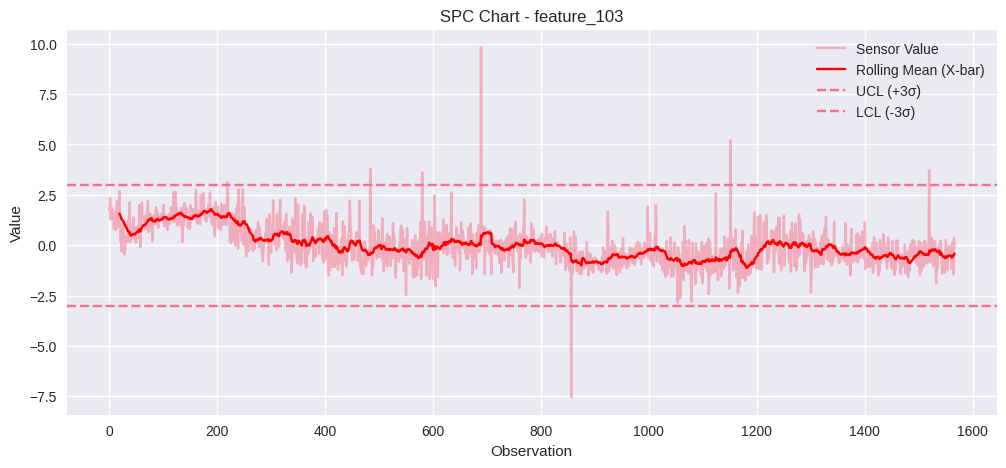

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data.values, label="Sensor Value", alpha=0.5)
plt.plot(rolling_mean.values, label="Rolling Mean (X-bar)", color="red")

plt.axhline(UCL, linestyle="--", label="UCL (+3σ)")
plt.axhline(LCL, linestyle="--", label="LCL (-3σ)")

plt.title(f"SPC Chart - {sensor}")
plt.xlabel("Observation")
plt.ylabel("Value")
plt.legend()
plt.show()

### **SPC Chart (feature_103) – Interpretation**

1. Control Limits

   UCL ≈ +3  
   LCL ≈ -3

👉 Since data is standardized — correct

2. Out-of-Control Points
You clearly have:
- Large spike around ~700 (≈ +10)
- Large drop around ~850 (≈ -7)
- Some spikes near ~1150

👉 These are:
Points beyond ±3σ → statistically abnormal

**Interpretation**
The process exhibits multiple out-of-control points where sensor values exceed the ±3σ control limits, indicating abnormal operating conditions.

3. Process Drift (Rolling Mean)

Look at red line:

👉 Starts higher → gradually declines → stabilizes

**Interpretation:**
- The rolling mean shows a gradual downward shift in the process, indicating potential process drift or recalibration over time.



**4.** **Stability**

Even though most points are within limits:

- Frequent spikes → instability


While the process remains largely within control limits, intermittent extreme deviations suggest episodic instability.

Step 7: Plot Variability (R Chart)

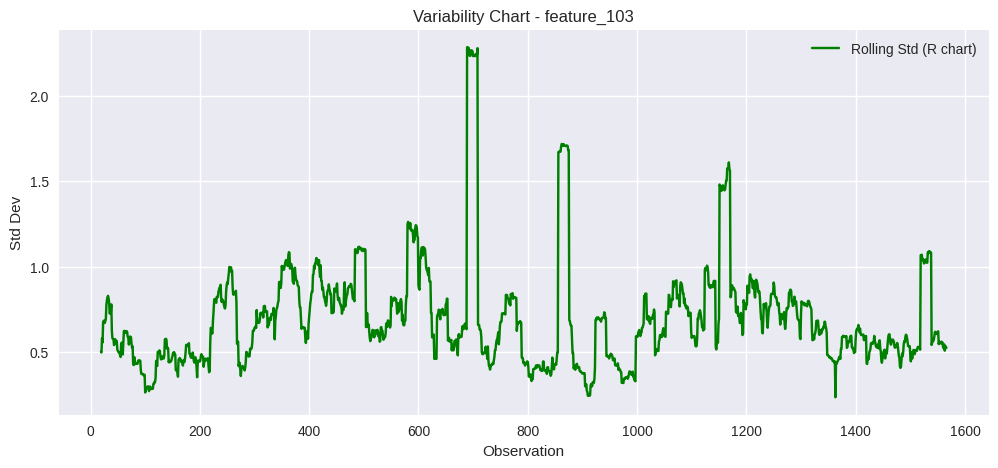

In [214]:
plt.figure(figsize=(12,5))
plt.plot(rolling_std.values, label="Rolling Std (R chart)", color="green")

plt.title(f"Variability Chart - {sensor}")
plt.xlabel("Observation")
plt.ylabel("Std Dev")
plt.legend()
plt.show()

# **R Chart (Variability Chart) – Interpretation**

1. Normal Behavior

   Most of the time: Std ≈ 0.5 – 1.0

 👉Normal variation



2. Sudden Variability Spikes
- Around 700 → huge spike (~2.3)
- Around 850 → spike (~1.7)
- Around 1150 → spike (~1.6)

**Interpretation:**

The variability chart reveals sudden increases in process variation at specific intervals, indicating unstable process behavior.